In [15]:
import os
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd


## Mateo CIFAR10

In [16]:
import os
import torch
import numpy as np

root = os.path.join("datasets", "CIFAR10")

for name in ["c_train.pt", "c_test.pt",
             "c_train_percentile_threshold_bool.pt",
             "c_test_percentile_threshold_bool.pt",
             "c_train_zero_shot_bool.pt",
             "c_test_zero_shot_bool.pt",
             "cifar10_concepts_train.pt"]:
    t = torch.load(os.path.join(root, name), map_location="cpu")
    print(name, type(t).__name__,
          getattr(t, "shape", len(t) if hasattr(t, "__len__") else None),
          getattr(t, "dtype", None))

train_idxs = np.load(os.path.join(root, "train_idxs.npy"))
val_idxs = np.load(os.path.join(root, "val_idxs.npy"))
print("split sizes:", train_idxs.shape, val_idxs.shape, "overlap:",
      len(np.intersect1d(train_idxs, val_idxs)))

c_tr = torch.load(os.path.join(root, "c_train.pt"), map_location="cpu").float()
c_te = torch.load(os.path.join(root, "c_test.pt"), map_location="cpu").float()
b_tr = torch.load(os.path.join(root, "c_train_percentile_threshold_bool.pt"), map_location="cpu")
z_tr = torch.load(os.path.join(root, "c_train_zero_shot_bool.pt"), map_location="cpu")

print("score range:", c_tr.min().item(), c_tr.max().item())

for tag, b in [("percentile", b_tr), ("zero-shot", z_tr)]:
    p = b.float().mean(0)
    print(f"{tag} prevalence  min={p.min():.4f} mean={p.mean():.4f} max={p.max():.4f}")

# where were the thresholds estimated?
for tag, ref in [("train only", c_tr), ("train+test", torch.cat([c_tr, c_te], 0))]:
    thr = ref.median(0).values
    print(f"{tag}: agreement with shipped labels =",
          ((c_tr > thr) == b_tr).float().mean().item())

c_train.pt Tensor torch.Size([50000, 143]) torch.float32
c_test.pt Tensor torch.Size([10000, 143]) torch.float32
c_train_percentile_threshold_bool.pt Tensor torch.Size([50000, 143]) torch.float32
c_test_percentile_threshold_bool.pt Tensor torch.Size([10000, 143]) torch.float32
c_train_zero_shot_bool.pt Tensor torch.Size([50000, 143]) torch.float32
c_test_zero_shot_bool.pt Tensor torch.Size([10000, 143]) torch.float32
cifar10_concepts_train.pt Tensor torch.Size([50000, 286]) torch.float32
split sizes: (40000,) (10000,) overlap: 0
score range: 0.08971765637397766 0.3324064612388611
percentile prevalence  min=0.4981 mean=0.4999 max=0.5020
zero-shot prevalence  min=0.0021 mean=0.8136 max=0.9999
train only: agreement with shipped labels = 0.9994373321533203
train+test: agreement with shipped labels = 1.0


In [17]:
print(b_tr.shape)

torch.Size([50000, 143])


In [18]:
for name in ["cifar10_train_clip_ViT-B16.pt", "cifar10_train_resnet50_layer4.pt",
             "cifar10_val_resnet50_layer4.pt", "cifar10_test_clip_ViT-B16.pt"]:
    t = torch.load(os.path.join(root, name), map_location="cpu")
    print(name, getattr(t, "shape", None), getattr(t, "dtype", None))

cifar10_train_clip_ViT-B16.pt torch.Size([50000, 512]) torch.float16
cifar10_train_resnet50_layer4.pt torch.Size([50000, 2048]) torch.float32
cifar10_val_resnet50_layer4.pt torch.Size([10000, 2048]) torch.float32
cifar10_test_clip_ViT-B16.pt torch.Size([10000, 512]) torch.float16


# Intervention curves for CIFAR-10

In [19]:
def extract_info_from_intervention_log(model_dir, model_type="scbm", dataset="cifar10", return_c_auroc=False):
    experiment_path = os.path.join("experiments", model_type, dataset)
    concepts_intervened_list = []
    y_accuracies_list = []
    c_accuracies_list = []
    c_auroc_list = []

    with open(os.path.join(experiment_path, model_dir, "intervention_log.txt"), "r") as f:
        lines = f.readlines()
        for line in lines:
            if "Intervention on" in line and "y_accuracy" in line and "c_accuracy" in line:
                m = re.search(r"Intervention on (\d+) concepts", line)
                if not m:
                    continue
                concepts_intervened = int(m.group(1))

                y_m = re.search(r"y_accuracy:\s*([0-9.]+)", line)
                c_m = re.search(r"c_accuracy:\s*([0-9.]+)", line)
                c_auroc_m = re.search(r"c_AUROC:\s*([0-9.]+)", line)

                y_accuracy = float(y_m.group(1)) * 100 if y_m else None
                c_accuracy = float(c_m.group(1)) * 100 if c_m else None
                c_auroc = float(c_auroc_m.group(1)) * 100 if c_auroc_m else None

                concepts_intervened_list.append(concepts_intervened)
                y_accuracies_list.append(y_accuracy)
                c_accuracies_list.append(c_accuracy)
                c_auroc_list.append(c_auroc)
    if return_c_auroc:
        return concepts_intervened_list, y_accuracies_list, c_accuracies_list, c_auroc_list
    return concepts_intervened_list, y_accuracies_list, c_accuracies_list


# Intervention curves Mateo

In [ ]:
model_dir_scbm_mateo = "mateo_cifar_2026-09-11_14-01-21_seed_0_df3a9"

model_dir_scbm_res_l_int_mateo = "mateo_cifar_L_int_extension_loss_weight_1_2026-09-11_14-01-24_seed_0_7baca"

model_dir_cem = "cem_p_int_0.25_mateo_cifar_cem_2026-09-11_14-34-01_seed_0_9c233"

In [ ]:
# --- Intervention curves: SCBM vs Res-SCBM vs CEM (Mateo CIFAR-10, Sept-11 seed-0 runs) ---
# Test split, random policy, 0 -> 143 concepts. Strategy is emp_perc for the SCBM family
# and hard for CEM (inherent to the model type, not a choice made here).
model_dir_scbm_mateo = "mateo_cifar_2026-09-11_14-01-21_seed_0_df3a9"
model_dir_scbm_res_l_int_mateo = "mateo_cifar_L_int_extension_loss_weight_1_2026-09-11_14-01-24_seed_0_7baca"
model_dir_cem = "cem_p_int_0.25_mateo_cifar_cem_2026-09-11_14-34-01_seed_0_9c233"

comparison_runs = {
    "SCBM": ("scbm", model_dir_scbm_mateo, "#2a78d6", "-"),
    "Res-SCBM (20 res., ext. $L_{int}$)": ("scbm_residual", model_dir_scbm_res_l_int_mateo, "#eb6834", "--"),
    "CEM ($p_{int}=0.25$)": ("cbm", model_dir_cem, "#1baf7a", "-."),
}

curves = {}
for label, (model_type, model_dir, color, ls) in comparison_runs.items():
    n, y_acc, c_acc, c_auroc = extract_info_from_intervention_log(
        model_dir, model_type=model_type, dataset="cifar10", return_c_auroc=True
    )
    curves[label] = dict(n=n, y=y_acc, c=c_acc, auroc=c_auroc, color=color, ls=ls)

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(9, 5.5))

for label, d in curves.items():
    ax.plot(d["n"], d["y"], linewidth=2.0, color=d["color"], linestyle=d["ls"], label=label)

# selective direct labels at the end of each line, nudged apart so they never collide
y_span = max(v for d in curves.values() for v in d["y"]) - min(
    v for d in curves.values() for v in d["y"]
)
min_gap = 0.045 * y_span
ends = sorted(((d["y"][-1], d["n"][-1]) for d in curves.values()), key=lambda t: t[0])
placed = []
for val, x_end in ends:
    y_text = val if not placed else max(val, placed[-1] + min_gap)
    placed.append(y_text)
    ax.annotate(
        f"{val:.1f}%",
        xy=(x_end, y_text),
        xytext=(6, 0),
        textcoords="offset points",
        va="center",
        fontsize=9,
        color="#52514e",
    )

ax.set_title(
    "Task accuracy under random concept intervention (CIFAR-10, 143 concepts)",
    fontsize=13,
    pad=12,
)
ax.set_xlabel("Number of concepts intervened on", fontsize=11)
ax.set_ylabel("Task accuracy (%)", fontsize=11)

ax.set_xlim(0, max(max(d["n"]) for d in curves.values()) * 1.06)
y_all = [v for d in curves.values() for v in d["y"]]
pad = max((max(y_all) - min(y_all)) * 0.1, 0.5)
ax.set_ylim(min(y_all) - pad, max(y_all) + pad)
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=12))

ax.grid(True, which="major", linestyle="--", alpha=0.35)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.legend(loc="lower right", frameon=True, fontsize=10)
fig.tight_layout()
plt.show()

# Table view of the same curves at a few intervention budgets
budgets = [0, 10, 25, 50, 75, 100, 143]
table = pd.DataFrame(
    {label: [d["y"][d["n"].index(b)] for b in budgets] for label, d in curves.items()},
    index=pd.Index(budgets, name="concepts intervened"),
).round(1)
display(table)

# Internvetion curves not Mateo

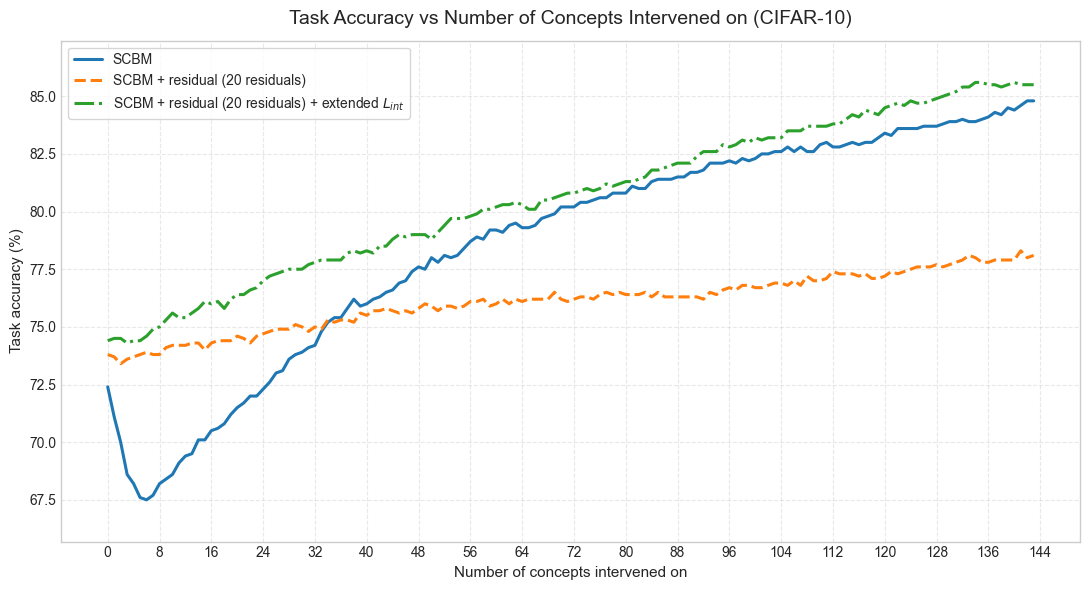

In [20]:
model_dir_scbm = "cifar10_scbm_2026-09-03_19-11-53_7001f"
model_dir_scbm_res_20 = "cifar10_scbm_res_20_2026-09-03_18-01-41_e9588"
model_dir_scbm_res_20_l_int_ext = (
    "cifar10_scbm_res_20_rtx_L_int_extension_loss_weight_1_2026-09-03_19-14-43_004be"
)

(concepts_intervened_list_scbm,
 y_accuracies_list_scbm,
 c_accuracies_list_scbm,
 c_auroc_list_scbm) = extract_info_from_intervention_log(
    model_dir_scbm, model_type="scbm", dataset="cifar10", return_c_auroc=True
)

(concepts_intervened_list_scbm_res_20,
 y_accuracies_list_scbm_res_20,
 c_accuracies_list_scbm_res_20,
 c_auroc_list_scbm_res_20) = extract_info_from_intervention_log(
    model_dir_scbm_res_20, model_type="scbm_residual", dataset="cifar10", return_c_auroc=True
)

(concepts_intervened_list_scbm_res_20_l_int_ext,
 y_accuracies_list_scbm_res_20_l_int_ext,
 c_accuracies_list_scbm_res_20_l_int_ext,
 c_auroc_list_scbm_res_20_l_int_ext) = extract_info_from_intervention_log(
    model_dir_scbm_res_20_l_int_ext, model_type="scbm_residual", dataset="cifar10", return_c_auroc=True
)

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    concepts_intervened_list_scbm,
    y_accuracies_list_scbm,
    linewidth=2.2,
    markersize=6,
    color="#1f77b4",
    label="SCBM",
)

ax.plot(
    concepts_intervened_list_scbm_res_20,
    y_accuracies_list_scbm_res_20,
    linewidth=2.2,
    markersize=6,
    color="#ff7f0e",
    linestyle="--",
    label="SCBM + residual (20 residuals)",
)

ax.plot(
    concepts_intervened_list_scbm_res_20_l_int_ext,
    y_accuracies_list_scbm_res_20_l_int_ext,
    linewidth=2.2,
    markersize=6,
    color="#2ca02c",
    linestyle="-.",
    label="SCBM + residual (20 residuals) + extended $L_{int}$",
)

ax.set_title(
    "Task Accuracy vs Number of Concepts Intervened on (CIFAR-10)",
    fontsize=14,
    pad=12,
)
ax.set_xlabel("Number of concepts intervened on", fontsize=11)
ax.set_ylabel("Task accuracy (%)", fontsize=11)

max_len = max(
    len(concepts_intervened_list_scbm),
    len(concepts_intervened_list_scbm_res_20),
    len(concepts_intervened_list_scbm_res_20_l_int_ext),
)
ax.xaxis.set_major_locator(MaxNLocator(integer=True, prune=None, nbins=min(20, max_len)))

y_min = min(
    min(y_accuracies_list_scbm),
    min(y_accuracies_list_scbm_res_20),
    min(y_accuracies_list_scbm_res_20_l_int_ext),
)
y_max = max(
    max(y_accuracies_list_scbm),
    max(y_accuracies_list_scbm_res_20),
    max(y_accuracies_list_scbm_res_20_l_int_ext),
)
pad = max((y_max - y_min) * 0.1, 0.5)
ax.set_ylim(y_min - pad, y_max + pad)

ax.grid(True, which="major", linestyle="--", alpha=0.45)
ax.legend(loc="best", frameon=True)
fig.tight_layout()
plt.show()

# Training curves for CIFAR-10

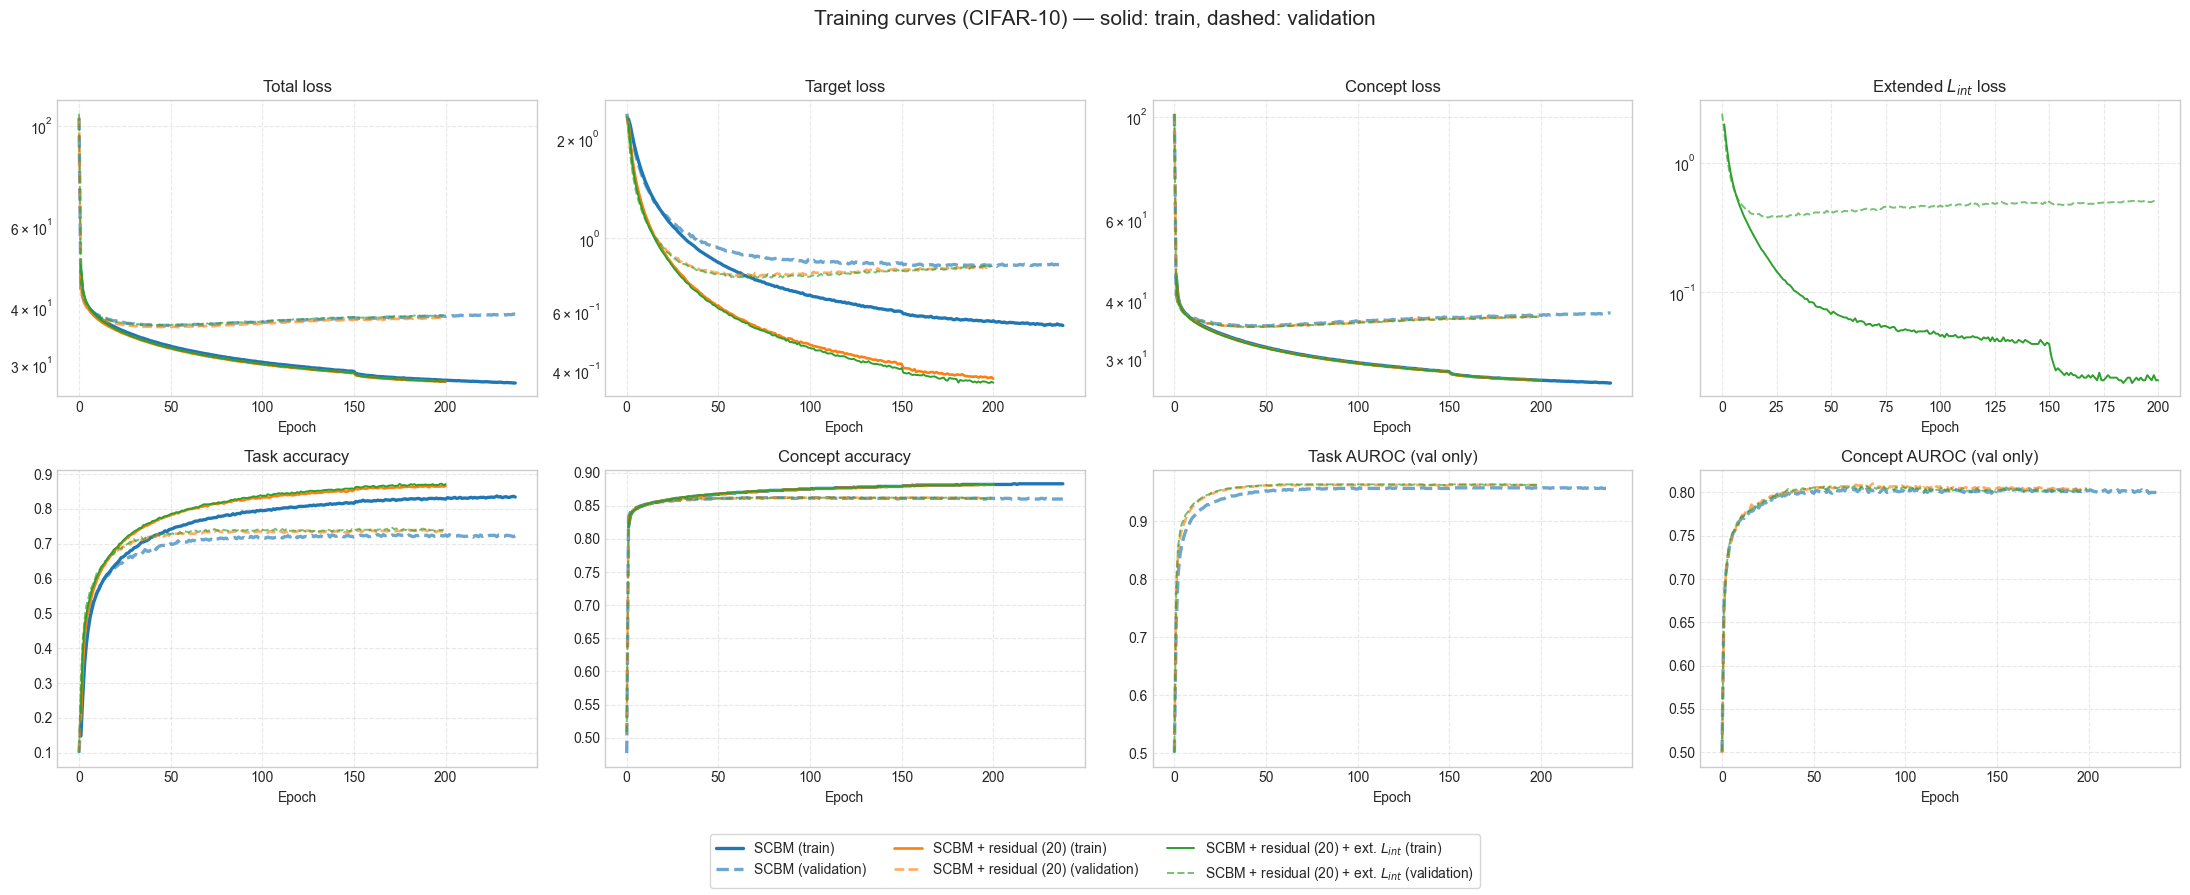

,run,epochs,train y_acc,val y_acc (last),val y_acc (best),val c_acc (best),val y_AUROC (best),val c_AUROC (best)
0,SCBM,238,0.834,0.723,0.726,0.862,0.959,0.805
1,SCBM + residual (20),200,0.866,0.734,0.740,0.862,0.964,0.810
2,SCBM + residual (20) + ext. $L_{int}$,200,0.871,0.741,0.746,0.862,0.965,0.808


In [21]:
# --- Training curves for the three CIFAR-10 runs ---
def parse_training_log(model_dir, model_type="scbm", dataset="cifar10"):
    """Parse log.txt into a tidy DataFrame with one row per (epoch, split)."""
    path = os.path.join("experiments", model_type, dataset, model_dir, "log.txt")
    rows = []
    with open(path, "r") as f:
        for line in f:
            m = re.match(r"Epoch (\d+), (Train|Validation)\s*:(.*)", line)
            if not m:
                continue
            row = {"epoch": int(m.group(1)), "split": m.group(2)}
            for k, v in re.findall(r"([A-Za-z_][A-Za-z_\-]*):\s*(-?[0-9.]+)", m.group(3)):
                row[k] = float(v)
            rows.append(row)
    return pd.DataFrame(rows)


runs = [
    ("SCBM", model_dir_scbm, "scbm", "#1f77b4"),
    ("SCBM + residual (20)", model_dir_scbm_res_20, "scbm_residual", "#ff7f0e"),
    ("SCBM + residual (20) + ext. $L_{int}$", model_dir_scbm_res_20_l_int_ext, "scbm_residual", "#2ca02c"),
]

logs = {label: parse_training_log(d, model_type=mt) for label, d, mt, _ in runs}

metrics = [
    ("total_loss", "Total loss"),
    ("target_loss", "Target loss"),
    ("concepts_loss", "Concept loss"),
    ("l_int_extension_loss", "Extended $L_{int}$ loss"),
    ("y_accuracy", "Task accuracy"),
    ("c_accuracy", "Concept accuracy"),
    ("y_AUROC", "Task AUROC (val only)"),
    ("c_AUROC", "Concept AUROC (val only)"),
]

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 4, figsize=(22, 9))

for ax, (metric, title) in zip(axes.ravel(), metrics):
    for i, (label, _, _, color) in enumerate(runs):
        df = logs[label]
        if metric not in df.columns:
            continue
        for split, ls in [("Train", "-"), ("Validation", "--")]:
            sub = df[(df["split"] == split) & df[metric].notna()]
            if sub.empty:
                continue
            ax.plot(sub["epoch"], sub[metric], ls, color=color, linewidth=2.4 - 0.5 * i,
                    alpha=1.0 if split == "Train" else 0.65,
                    label=f"{label} ({split.lower()})")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Epoch", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.45)
    if metric.endswith("loss"):
        ax.set_yscale("log")

handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=True, fontsize=10)
fig.suptitle("Training curves (CIFAR-10) — solid: train, dashed: validation", fontsize=15)
fig.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()

# final-epoch / best-val summary
summary = []
for label, _, _, _ in runs:
    df = logs[label]
    val = df[df["split"] == "Validation"]
    tr = df[df["split"] == "Train"]
    summary.append({
        "run": label,
        "epochs": int(df["epoch"].max()),
        "train y_acc": tr["y_accuracy"].iloc[-1],
        "val y_acc (last)": val["y_accuracy"].iloc[-1],
        "val y_acc (best)": val["y_accuracy"].max(),
        "val c_acc (best)": val["c_accuracy"].max(),
        "val y_AUROC (best)": val["y_AUROC"].max(),
        "val c_AUROC (best)": val["c_AUROC"].max(),
    })
display(pd.DataFrame(summary).round(4))